---
title: "GCNs on the Cora Citation Network"
category: "Deep Learning"
tags:
  - deep-learning
  - graph-neural-networks
  - gcn
  - node-classification
  - semi-supervised-learning
  - cora
date: 2026-07-31
status: evergreen
description: "Compare a feature-only MLP with graph convolution and an edge-rewiring ablation on Cora under a low-label node-classification split."
sources:
  - https://arxiv.org/abs/1609.02907
  - https://arxiv.org/abs/1603.08861
  - https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz
notebook_page: false
---

## Question

Can citation edges improve paper-topic classification when only 20 papers per class are labeled?

Cora makes the comparison concrete. Each node is a machine-learning paper represented by a binary bag-of-words vector. An edge records a citation. The target is one of seven research topics. A feature-only multilayer perceptron sees each abstract vocabulary vector in isolation. A graph convolutional network can mix that vector with cited and citing papers before classifying it.

The experiment also trains the same GCN on an endpoint-shuffled graph. That null keeps the feature matrix, labels, edge count, and directed source/destination degree sequences before duplicate removal. Its lost semantic structure helps separate the value of meaningful neighborhoods from extra parameters or smoothing alone.


In [1]:
import os
import platform
import random
import sys
import tarfile
import time
import warnings
from copy import deepcopy
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
plt.style.use("seaborn-v0_8-whitegrid")

SPLIT_SEED = 7
MODEL_SEEDS = [0, 1, 2, 3, 4]
random.seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "content").is_dir() and (candidate / "package.json").exists():
            return candidate
    raise RuntimeError("Run the notebook from inside the notes repository")


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "work" / "notebook-data" / "cora"
DEVICE = torch.device("cpu")
print({
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "numpy": np.__version__,
    "platform": platform.platform(),
    "device": str(DEVICE),
})


{'python': '3.12.13', 'torch': '2.13.0', 'numpy': '2.5.1', 'platform': 'macOS-26.5-arm64-arm-64bit', 'device': 'cpu'}


## Data and Provenance

The [LINQS Cora archive](https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz) contains 2,708 papers, 1,433 binary word indicators, seven topic labels, and 5,429 citation records. The notebook downloads that archive into the ignored `work/notebook-data/cora/` directory. No downloaded data enters Git.

The split follows the low-label scale used by [Planetoid](https://arxiv.org/abs/1603.08861) and the [GCN paper](https://arxiv.org/abs/1609.02907): 20 training labels per class, 500 validation nodes, and 1,000 test nodes. This notebook draws one deterministic stratified training set and then samples validation and test nodes from the remainder. Its split is reproducible, though it is not the serialized Planetoid public split, so its accuracy should not be compared point-for-point with the paper's table.


In [2]:
CORA_URL = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
ARCHIVE = DATA_DIR / "cora.tgz"
CONTENT = DATA_DIR / "cora" / "cora.content"
CITES = DATA_DIR / "cora" / "cora.cites"

if not CONTENT.exists() or not CITES.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not ARCHIVE.exists():
        urlretrieve(CORA_URL, ARCHIVE)
    with tarfile.open(ARCHIVE, "r:gz") as bundle:
        bundle.extractall(DATA_DIR, filter="data")

paper_ids = []
feature_rows = []
label_names = []
with CONTENT.open(encoding="utf-8") as handle:
    for line in handle:
        fields = line.split()
        paper_ids.append(fields[0])
        feature_rows.append([int(value) for value in fields[1:-1]])
        label_names.append(fields[-1])

node_for_id = {paper_id: index for index, paper_id in enumerate(paper_ids)}
classes = sorted(set(label_names))
class_for_name = {name: index for index, name in enumerate(classes)}
labels_np = np.array([class_for_name[name] for name in label_names], dtype=np.int64)
features_np = np.asarray(feature_rows, dtype=np.float32)
features_np /= np.maximum(features_np.sum(axis=1, keepdims=True), 1.0)

citation_pairs = []
with CITES.open(encoding="utf-8") as handle:
    for line in handle:
        cited, citing = line.split()
        if cited in node_for_id and citing in node_for_id:
            citation_pairs.append((node_for_id[cited], node_for_id[citing]))

citations_np = np.asarray(citation_pairs, dtype=np.int64).T
edges_np = np.concatenate([citations_np, citations_np[::-1]], axis=1)
num_nodes, num_features = features_np.shape
num_classes = len(classes)

rng = np.random.default_rng(SPLIT_SEED)
train_parts = []
for class_id in range(num_classes):
    candidates = np.flatnonzero(labels_np == class_id)
    train_parts.append(rng.choice(candidates, size=20, replace=False))
train_idx_np = np.sort(np.concatenate(train_parts))
remaining = np.setdiff1d(np.arange(num_nodes), train_idx_np)
rng.shuffle(remaining)
val_idx_np = np.sort(remaining[:500])
test_idx_np = np.sort(remaining[500:1500])

x = torch.tensor(features_np, dtype=torch.float32, device=DEVICE)
y = torch.tensor(labels_np, dtype=torch.long, device=DEVICE)
train_idx = torch.tensor(train_idx_np, dtype=torch.long, device=DEVICE)
val_idx = torch.tensor(val_idx_np, dtype=torch.long, device=DEVICE)
test_idx = torch.tensor(test_idx_np, dtype=torch.long, device=DEVICE)

edge_homophily = float(
    (labels_np[citations_np[0]] == labels_np[citations_np[1]]).mean()
)
print({
    "nodes": num_nodes,
    "citation_records": citations_np.shape[1],
    "features": num_features,
    "classes": num_classes,
    "train/validation/test": (len(train_idx), len(val_idx), len(test_idx)),
    "citation_label_agreement": round(edge_homophily, 3),
})


{'nodes': 2708, 'citation_records': 5429, 'features': 1433, 'classes': 7, 'train/validation/test': (140, 500, 1000), 'citation_label_agreement': 0.814}


## Models and Ablation

For adjacency matrix (A), add self-loops and normalize with

$$
\hat{A} = \tilde{D}^{-1/2}(A + I)\tilde{D}^{-1/2}.
$$

The two-layer GCN computes

$$
Z = \hat{A}\,\operatorname{Dropout}\left(\operatorname{ReLU}(\hat{A}XW_0)\right)W_1.
$$

The MLP removes both multiplications by (hat{A}) while retaining the same width, nonlinearity, dropout, optimizer, and labeled nodes. The rewired GCN permutes edge destinations before symmetrization and normalization. It still propagates the same node features through a graph of similar density, but citations no longer point toward their observed papers.

Full-batch training uses Adam, cross-entropy on the 140 labeled nodes, validation-based early stopping, and five initialization seeds. The test labels remain untouched until each seed's best validation checkpoint has been restored.


In [3]:
def normalized_adjacency(edge_index: np.ndarray, n: int) -> torch.Tensor:
    loops = np.arange(n, dtype=np.int64)
    indices_np = np.concatenate(
        [edge_index, np.stack([loops, loops])], axis=1
    )
    indices = torch.tensor(indices_np, dtype=torch.long, device=DEVICE)
    raw = torch.sparse_coo_tensor(
        indices,
        torch.ones(indices.shape[1], device=DEVICE),
        (n, n),
    ).coalesce()
    indices = raw.indices()
    values = torch.ones(indices.shape[1], device=DEVICE)
    degree = torch.zeros(n, device=DEVICE)
    degree.scatter_add_(0, indices[0], values)
    norm = degree[indices[0]].rsqrt() * degree[indices[1]].rsqrt()
    return torch.sparse_coo_tensor(indices, norm, (n, n)).coalesce()


def shuffled_edges(edge_index: np.ndarray, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    shuffled = edge_index.copy()
    shuffled[1] = rng.permutation(shuffled[1])
    return shuffled[:, shuffled[0] != shuffled[1]]


adjacency = normalized_adjacency(edges_np, num_nodes)
rewired_edges_np = shuffled_edges(edges_np, seed=101)
rewired_adjacency = normalized_adjacency(rewired_edges_np, num_nodes)
x_aggregated = torch.sparse.mm(adjacency, x)
x_rewired = torch.sparse.mm(rewired_adjacency, x)

rewired_homophily = float(
    (labels_np[rewired_edges_np[0]] == labels_np[rewired_edges_np[1]]).mean()
)
print({
    "observed_edge_label_agreement": round(edge_homophily, 3),
    "rewired_edge_label_agreement": round(rewired_homophily, 3),
})


class MLP(nn.Module):
    def __init__(self, d_in: int, d_hidden: int, d_out: int):
        super().__init__()
        self.input = nn.Linear(d_in, d_hidden)
        self.output = nn.Linear(d_hidden, d_out)

    def encode(self, features: torch.Tensor) -> torch.Tensor:
        return F.relu(self.input(features))

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        hidden = F.dropout(self.encode(features), p=0.5, training=self.training)
        return self.output(hidden)


class GCN(nn.Module):
    def __init__(self, d_in: int, d_hidden: int, d_out: int, graph: torch.Tensor):
        super().__init__()
        self.input = nn.Linear(d_in, d_hidden)
        self.output = nn.Linear(d_hidden, d_out)
        self.graph = graph

    def encode(self, aggregated_features: torch.Tensor) -> torch.Tensor:
        return F.relu(self.input(aggregated_features))

    def forward(self, aggregated_features: torch.Tensor) -> torch.Tensor:
        hidden = F.dropout(
            self.encode(aggregated_features), p=0.5, training=self.training
        )
        hidden = torch.sparse.mm(self.graph, hidden)
        return self.output(hidden)


{'observed_edge_label_agreement': 0.814, 'rewired_edge_label_agreement': 0.171}


In [4]:
def accuracy(logits: torch.Tensor, indices: torch.Tensor) -> float:
    return float((logits[indices].argmax(dim=1) == y[indices]).float().mean())


def fit(model: nn.Module, inputs: torch.Tensor, seed: int):
    torch.manual_seed(seed)
    model.reset_parameters() if hasattr(model, "reset_parameters") else None
    for module in model.modules():
        if isinstance(module, nn.Linear):
            module.reset_parameters()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    best_state = None
    best_val = -1.0
    wait = 0
    history = {"loss": [], "train": [], "validation": []}

    for epoch in range(400):
        model.train()
        optimizer.zero_grad()
        logits = model(inputs)
        loss = F.cross_entropy(logits[train_idx], y[train_idx])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(inputs)
            train_accuracy = accuracy(logits, train_idx)
            val_accuracy = accuracy(logits, val_idx)
        history["loss"].append(float(loss.detach()))
        history["train"].append(train_accuracy)
        history["validation"].append(val_accuracy)

        if val_accuracy > best_val + 1e-5:
            best_val = val_accuracy
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
        if wait >= 50:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        logits = model(inputs)
    return {
        "test_accuracy": accuracy(logits, test_idx),
        "best_validation_accuracy": best_val,
        "epochs": len(history["loss"]),
        "history": history,
        "logits": logits,
        "model": model,
    }


configurations = {
    "MLP (features only)": lambda: (
        MLP(num_features, 16, num_classes).to(DEVICE), x
    ),
    "GCN (citations)": lambda: (
        GCN(num_features, 16, num_classes, adjacency).to(DEVICE), x_aggregated
    ),
    "GCN (rewired edges)": lambda: (
        GCN(num_features, 16, num_classes, rewired_adjacency).to(DEVICE), x_rewired
    ),
}

started = time.perf_counter()
runs = {name: [] for name in configurations}
for name, factory in configurations.items():
    for seed in MODEL_SEEDS:
        model, inputs = factory()
        runs[name].append(fit(model, inputs, seed))
elapsed = time.perf_counter() - started

for name, model_runs in runs.items():
    scores = np.array([run["test_accuracy"] for run in model_runs])
    epochs = np.array([run["epochs"] for run in model_runs])
    print(
        f"{name:22s} test accuracy={scores.mean():.3f} +/- {scores.std(ddof=1):.3f} "
        f"epochs={epochs.mean():.0f}"
    )
print(f"total training time: {elapsed:.1f}s")


MLP (features only)    test accuracy=0.543 +/- 0.028 epochs=212
GCN (citations)        test accuracy=0.773 +/- 0.008 epochs=201
GCN (rewired edges)    test accuracy=0.195 +/- 0.022 epochs=133
total training time: 6.6s


## Reading the Result

The bar chart summarizes variability across initialization seeds. Learning curves come from seed 0 and show the validation signal used for checkpoint selection. The embedding plot projects the GCN's 16-dimensional hidden states with PCA; labels color points for interpretation only and do not enter PCA.


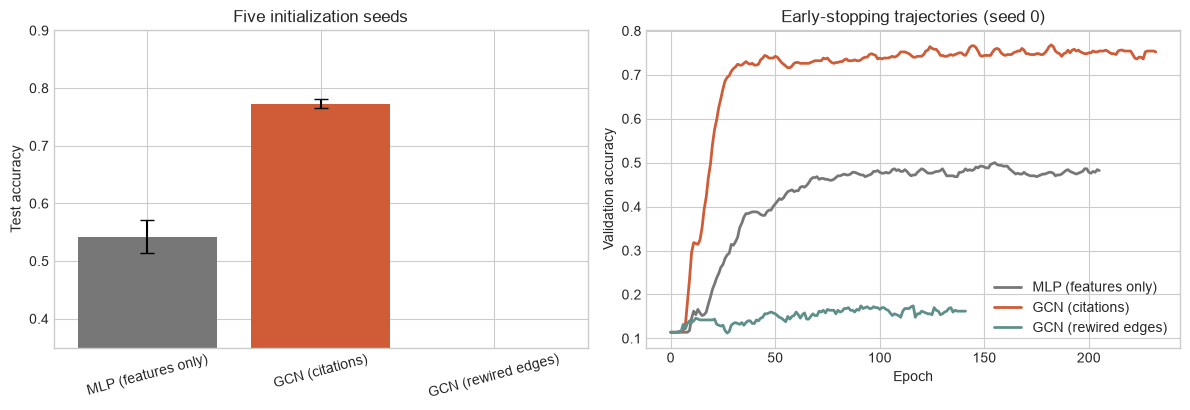

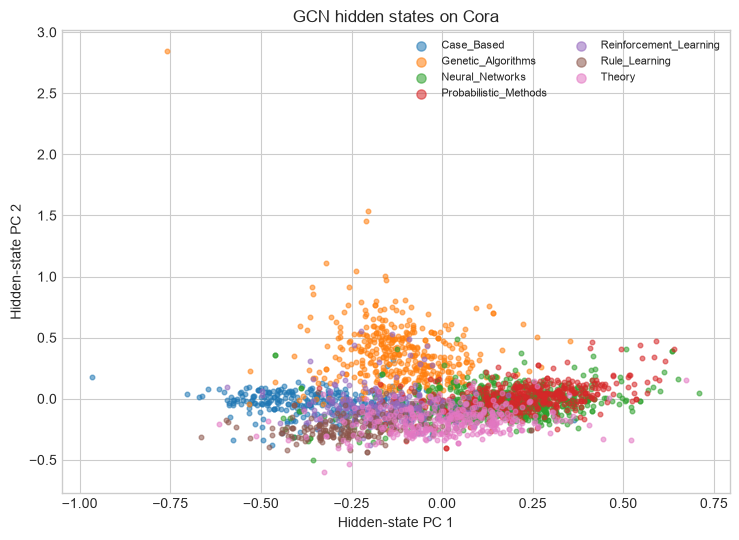

In [5]:
names = list(runs)
means = [np.mean([run["test_accuracy"] for run in runs[name]]) for name in names]
stds = [np.std([run["test_accuracy"] for run in runs[name]], ddof=1) for name in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colors = ["#777777", "#cf5c36", "#5f8f8b"]
axes[0].bar(names, means, yerr=stds, capsize=5, color=colors)
axes[0].set_ylim(0.35, 0.9)
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Five initialization seeds")
axes[0].tick_params(axis="x", rotation=15)

for name, color in zip(names, colors):
    curve = runs[name][0]["history"]["validation"]
    axes[1].plot(curve, label=name, color=color, linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Early-stopping trajectories (seed 0)")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

best_gcn = max(runs["GCN (citations)"], key=lambda run: run["best_validation_accuracy"])
with torch.no_grad():
    hidden = best_gcn["model"].encode(x_aggregated).cpu()
centered = hidden - hidden.mean(dim=0, keepdim=True)
_, _, components = torch.pca_lowrank(centered, q=2)
projected = (centered @ components).numpy()

plt.figure(figsize=(7.5, 5.5))
for class_id, class_name in enumerate(classes):
    mask = labels_np == class_id
    plt.scatter(
        projected[mask, 0],
        projected[mask, 1],
        s=11,
        alpha=0.55,
        label=class_name,
    )
plt.xlabel("Hidden-state PC 1")
plt.ylabel("Hidden-state PC 2")
plt.title("GCN hidden states on Cora")
plt.legend(markerscale=2, fontsize=8, frameon=False, ncol=2)
plt.tight_layout()
plt.show()


## Interpretation

Across five initialization seeds, the citation GCN reached mean test accuracy $0.773 \pm 0.008$, where the interval is one sample standard deviation. The feature-only MLP reached $0.543 \pm 0.028$. The 23.0 percentage-point gap measures the value of neighborhood propagation for this fixed low-label split and implementation.

Observed citation endpoints shared a topic 81.4% of the time. Endpoint shuffling reduced that agreement to 17.1%, and the same GCN architecture then reached $0.195 \pm 0.022$ test accuracy. Smoothing through arbitrary neighbors destroyed useful signal. These measurements apply to a homophilous citation graph. They do not establish performance on heterophilous graphs, inductive graph tasks, or datasets with abundant labels.

## Environment and Reproduction

The environment cell records the exact Python, PyTorch, NumPy, platform, and device values stored with this run. Data downloads to `work/notebook-data/cora/`. From the repository root, execute and publish with:

```sh
.venv/bin/python scripts/execute_notebooks.py content/ml/deep-learning/graph-neural-networks.ipynb
npm run render:notebooks
npm run build
```
